In [1]:
import torch
from torch import nn
from d2l import torch as d2l

def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU()

    )


In [4]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Dropout(0.5),
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)

In [5]:
X = torch.randn(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'out shape:\t', X.shape)

Sequential out shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d out shape:	 torch.Size([1, 96, 26, 26])
Sequential out shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d out shape:	 torch.Size([1, 256, 12, 12])
Sequential out shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d out shape:	 torch.Size([1, 384, 5, 5])
Dropout out shape:	 torch.Size([1, 384, 5, 5])
Sequential out shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d out shape:	 torch.Size([1, 10, 1, 1])
Flatten out shape:	 torch.Size([1, 10])


loss 0.264, train acc 0.902, test acc 0.899
480.6 examples/sec on cuda:0


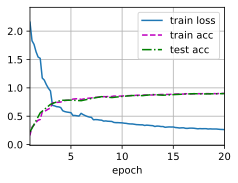

In [16]:
lr, num_epochs, batch_size = 0.1, 20, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [10]:
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.memory_reserved() / 1024**2, "MB")
print(torch.cuda.max_memory_allocated() / 1024**2, "MB")

15.8125 MB
2022.0 MB
1029.43017578125 MB


In [14]:
torch.cuda.reset_peak_memory_stats()
device = d2l.try_gpu()
for X, y in train_iter:
    break 
X, y = X.to(device), y.to(device)

with torch.no_grad():
    net(X)
print("预测显存峰值", torch.cuda.max_memory_allocated() / 1024**2, "MB")

y_hat = net(X)
loss = nn.CrossEntropyLoss()
l = loss(y_hat, y)
l.backward()
print("训练显存峰值：", torch.cuda.max_memory_allocated()/1024**2, "MB")

预测显存峰值 313.6884765625 MB
训练显存峰值： 1036.5068359375 MB
